In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
star_df = pd.read_csv(r"C:\Users\Acer_Nitro\Documents\cleaned_star_data.csv")
star_df.sample(10)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
111,3605,126000.00000,1124.00000,-10.810,5,Red,M
205,19920,0.00156,0.01420,11.340,2,Blue,B
2,2600,0.00030,0.10200,18.700,0,Red,M
229,21738,748890.00000,92.00000,-7.346,4,Blue,O
223,23440,537430.00000,81.00000,-5.975,4,Blue,O
88,13720,0.00018,0.00892,12.970,2,White,F
71,3607,0.02200,0.38000,10.120,1,Red,M
37,6380,1.35000,0.98000,2.930,3,Yellow-White,F
148,7723,0.00014,0.00878,14.810,2,White,A
29,7230,0.00008,0.01300,14.080,2,Red,F


In [3]:
star_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


In [4]:
folder_name = 'star_plots'                     
os.makedirs(folder_name, exist_ok=True)        
base_dir = f'/content/{folder_name}/'  

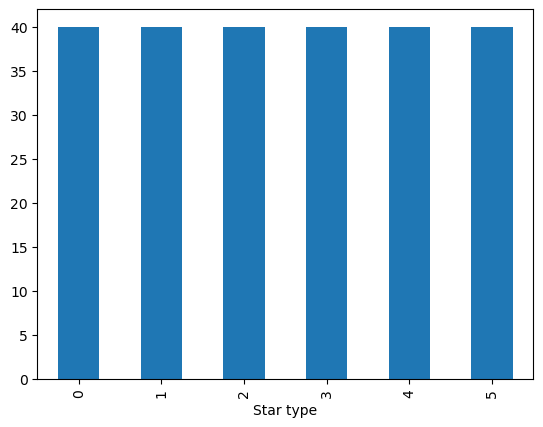

In [5]:
# MATPLOTLIB
star_df['Star type'].value_counts().plot(kind='bar')
plt.show()

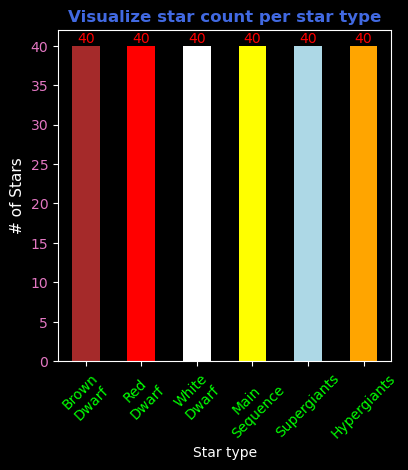

In [7]:
# CUSTOMIZE THE PLOT
plt.figure(figsize=(4.3,4.3))
plt.style.use('dark_background')
ax = star_df['Star type'].value_counts().plot(kind='bar', color=['brown', 'red', 'white', 'yellow', 'lightblue', 'orange'])
ax.bar_label(ax.containers[0], color='red')
plt.title('Visualize star count per star type', color='royalblue', weight='bold')
plt.yticks(color='tab:pink')
plt.ylabel('# of Stars', color='white', fontsize=11)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5],
           labels=['Brown\nDwarf', 'Red\nDwarf', 'White\nDwarf', 'Main\nSequence', 'Supergiants', 'Hypergiants'],
           rotation=45, color='lime')
os.makedirs(os.path.dirname(base_dir), exist_ok=True)
plt.savefig(base_dir+'barplot_star_count.png')
plt.show()

C:\Users\Acer_Nitro\AppData\Local\Temp\ipykernel_12960\952258463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=star_df['Star color'].value_counts().index,


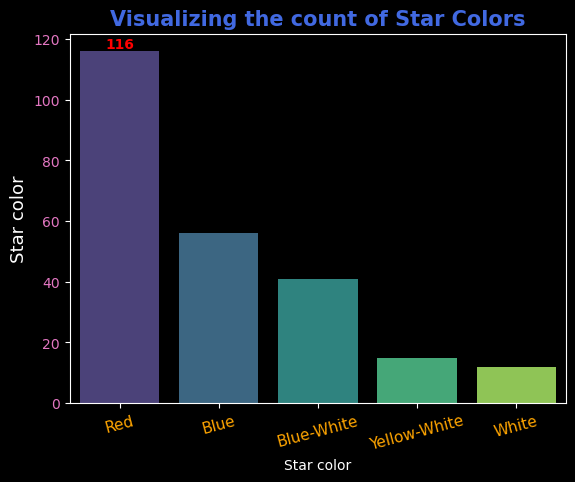

In [8]:
# MATPLOTLIB + SEABORN
ax = sns.barplot(x=star_df['Star color'].value_counts().index,
            y=star_df['Star color'].value_counts(),
            palette='viridis')
ax.bar_label(ax.containers[0], color='red', weight='bold')
plt.title('Visualizing the count of Star Colors', color='royalblue', fontsize=15, weight='bold')
plt.xticks(rotation=15, color='orange', fontsize=11)
plt.ylabel('Star color',color='white', fontsize=13)
plt.yticks(color='tab:pink')
plt.savefig(base_dir+'star_colors_viz.png')
plt.show()

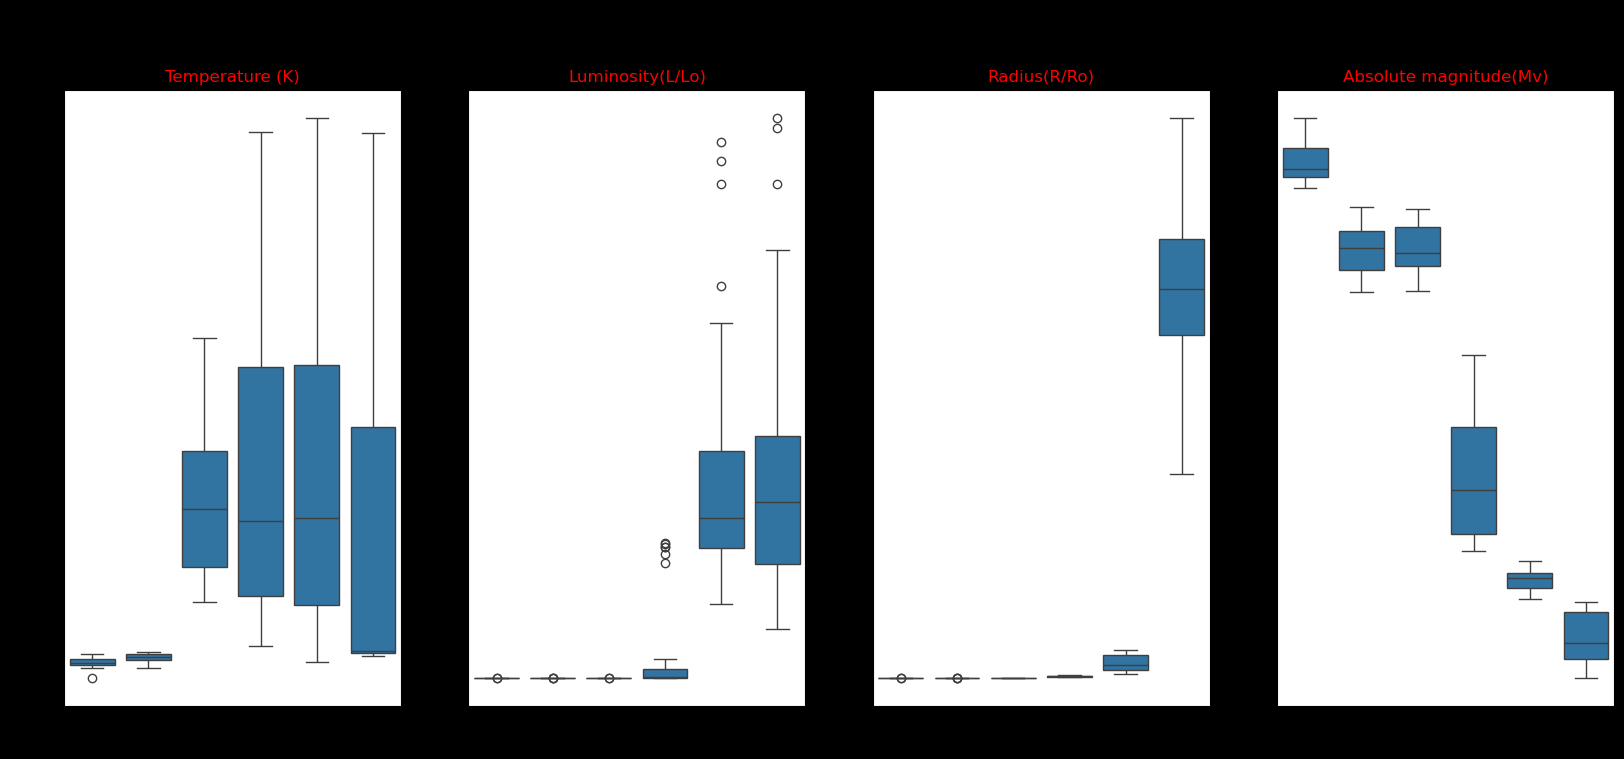

In [9]:
plt.figure(figsize=(20,8))
plt.style.use('default')
plt.suptitle('Visualizing the outliers in Numeric features of Star Type',
             color='black', weight='bold', fontsize=15)

for i in range(4):
  plt.subplot(1, 4, i+1)
  sns.boxplot(x=star_df['Star type'], y=star_df.iloc[:, i])
  plt.title(star_df.columns[i], color='red')
  plt.ylabel('')

plt.savefig(base_dir+'boxplot_star_type.png')

In [10]:
def line_subplot(star_df, colors, i):
  plt.subplot(4, 1, i+1)
  plt.plot(star_df.iloc[:,i], color=colors[i])
  plt.title(star_df.columns[i], color='red')

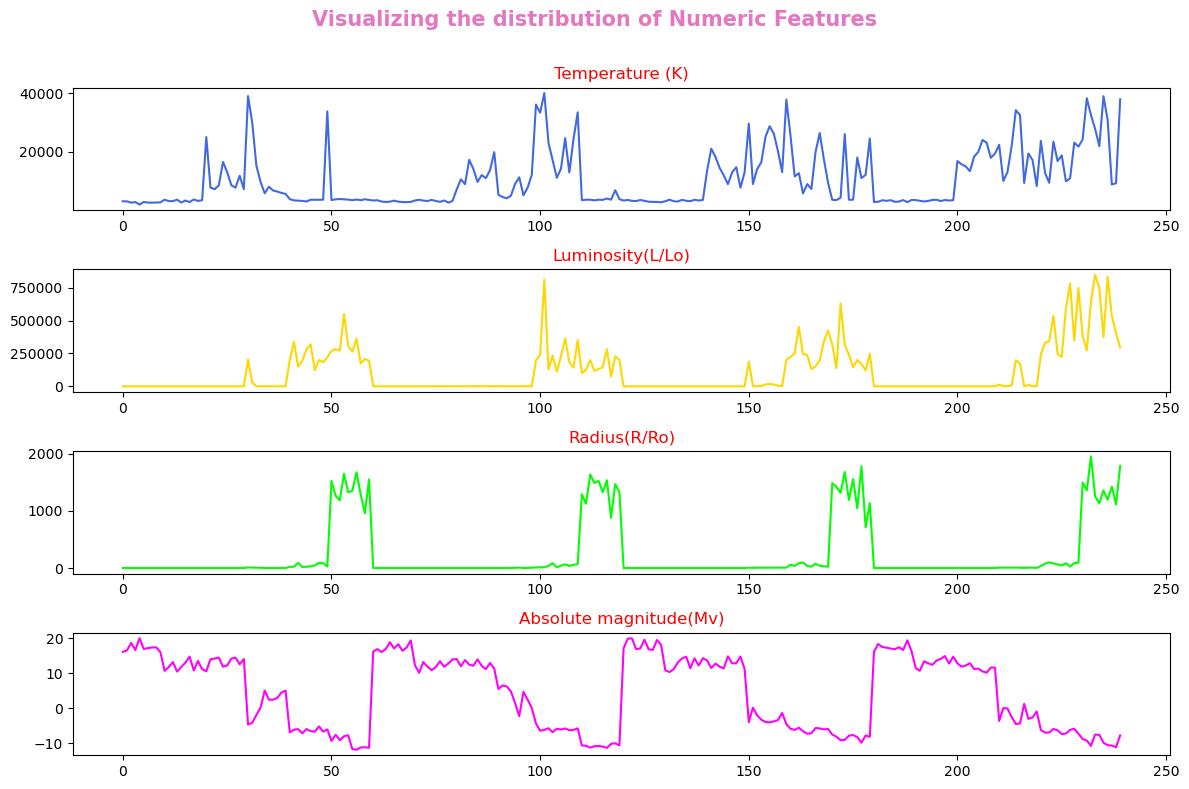

In [11]:
# LINE PLOTS
colors = ['royalblue', 'gold', 'lime', 'magenta']

plt.figure(figsize=(12,8))
plt.suptitle('Visualizing the distribution of Numeric Features\n',
             color='tab:pink', fontsize=15, weight='bold')

for i in range(4):
  line_subplot(star_df, colors, i)
    
plt.tight_layout()
plt.savefig(base_dir+'line_subplot.png')
plt.show()

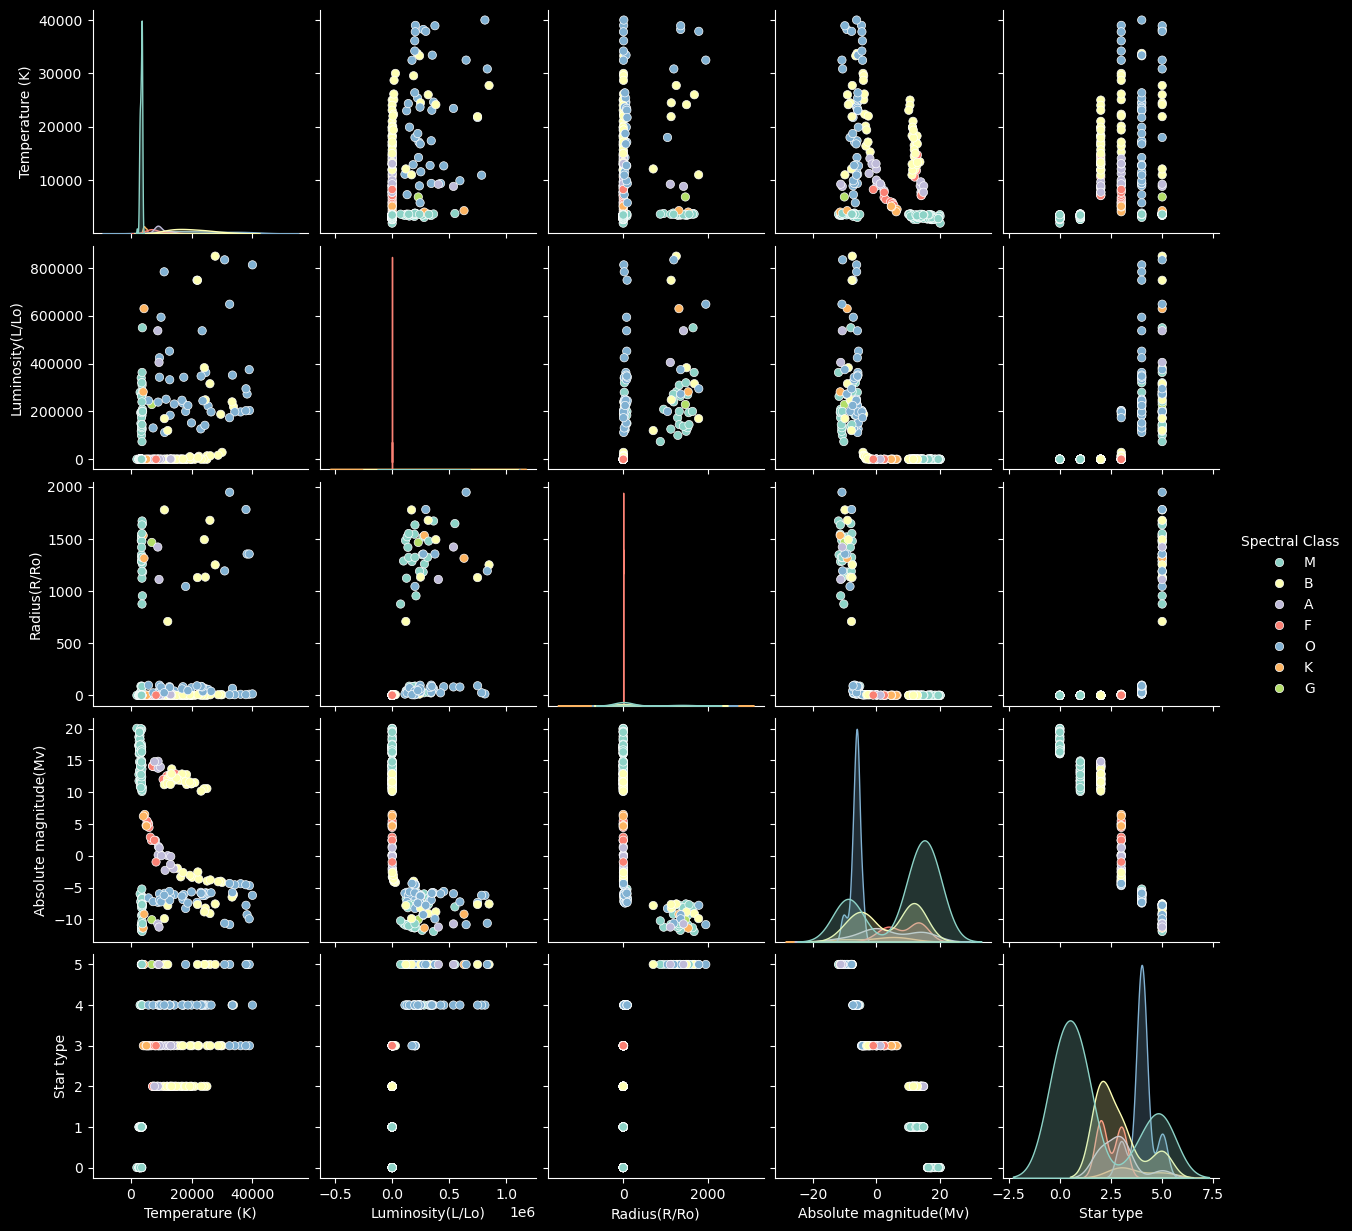

In [12]:
# PAIRPLOT
plt.style.use('dark_background')
sns.pairplot(star_df, hue='Spectral Class')
plt.savefig(base_dir+'pairplot.png')
plt.show()

In [13]:
star_type = star_df['Star type'].values
temperature = star_df['Temperature (K)'].values
abs_mag = star_df['Absolute magnitude(Mv)'].values

star_types = {
    0: {'label': 'Brown Dwarf', 'color': 'brown', 'size': 30, 'marker': '.'},
    1: {'label': 'Red Dwarf', 'color': 'red', 'size': 35, 'marker': '.'},
    2: {'label': 'White Dwarf', 'color': 'white', 'size': 40, 'marker': '.'},
    3: {'label': 'Main Sequence', 'color': 'cyan', 'size': 30, 'marker': 'o'},
    4: {'label': 'Supergiants', 'color': 'orange', 'size': 100, 'marker': 'o'},
    5: {'label': 'Hypergiants', 'color': 'maroon', 'size': 150, 'marker': 'o'}
}

In [ ]:
# PLOTTING A HR DIAGRAM FOR TEMP VS ABS MAG 

axes = []
labels = set()

plt.figure(figsize=(10, 6))

for i in range(len(star_type)):
  properties = star_types[star_type[i]]

  if properties['label'] not in labels:
    ax = plt.scatter(temperature[i], abs_mag[i],
                    s=properties['size'],
                    c=properties['color'],
                    marker=properties['marker'],
                    label=properties['label'])
    axes.append(ax)
    labels.add(properties['label'])
  else:
    plt.scatter(temperature[i], abs_mag[i],
                s=properties['size'],
                c=properties['color'],
                marker=properties['marker'],
                label=properties['label'])

ax_sun = plt.scatter(5778, 4.83, s=75, c="yellow", marker='o', label="Sun")
axes.append(ax_sun)
labels.add("Sun")

plt.title(f"Hertzsprung - Russell Diagram for {len(star_type)} Stars", fontsize=15, color='royalblue')
plt.ylabel("Absolute Magnitude (Mv)", fontsize=13, color='tab:pink')
plt.xlabel("Temperature (K)", fontsize=13, color='tab:pink')
plt.legend(handles=axes)

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.savefig(base_dir+'hr_diagram.png')
plt.show()